# Susceptibility model v1: which factors predict doline locations (20250820)

Detection-by-thresholding (notebooks 01-04) caps out around 40-65% recall for a reviewable candidate count -- logged as a likely ceiling for that approach, not a tuning problem. This notebook tries a different question: not "where are the dolines" but "which environmental covariates predict doline presence, and how" -- the same framing as karst/landslide susceptibility mapping or a presence-background SDM (MaxEnt etc).

Scope: single epoch (20250820, richest dataset -- LiDAR DSM + RGB ortho), Random Forest. No multispectral or thermal for this date (see `data/CLAUDE.md`), so the covariate stack here is topographic + RGB-brightness only.

**This is a benchmark/pipeline-validation run** -- fieldwork lands in ~2 weeks (26-28 Aug 2026) and will bring better/fresh data, at which point this gets a proper rerun. Today's goal is just confirming the pipeline works end to end, not a final result.

In [1]:
import os
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("pyproject.toml not found in any parent directory")


os.chdir(_find_repo_root(Path.cwd()))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

from master_thesis.doline_detection import random_points_in_polygon, sample_raster
from master_thesis.terrain_covariates import (
    compute_aspect,
    compute_plan_curvature,
    compute_profile_curvature,
    compute_roughness,
    compute_slope,
    compute_wetness_index,
)

DATE = "20250820"
INTERIM = Path("data/interim")
PROCESSED = Path("data/processed")
AOI = Path(f"data/raw/{DATE}/{DATE}_aoi.gpkg")
MANUAL_POINTS = Path("data/manual/Sinkholes.shp")
CLIPPED_DEM = INTERIM / f"{DATE}_terra_ppk_lidar_dsm_clip.tif"

N_BACKGROUND = 300
SEED = 0
N_SPATIAL_BLOCKS_PER_SIDE = 4  # coarse grid for spatial CV grouping

assert CLIPPED_DEM.exists(), "expected clipped DSM from earlier notebooks"

## Terrain covariates

Slope/aspect/curvature/roughness are direct local derivatives -- computed straight off the real (unfilled) DSM so the pit micro-topography that's diagnostic here isn't smoothed away. TWI needs a depression-filled DEM as an internal step for its flow-routing algorithm to work at all, but that filled DEM is scratch-only and never used anywhere else.

In [2]:
stem = CLIPPED_DEM.stem
new_covariates = {
    "slope": (INTERIM / f"{stem}_slope.tif", compute_slope),
    "aspect": (INTERIM / f"{stem}_aspect.tif", compute_aspect),
    "plan_curvature": (INTERIM / f"{stem}_plan_curv.tif", compute_plan_curvature),
    "profile_curvature": (INTERIM / f"{stem}_profile_curv.tif", compute_profile_curvature),
    "roughness": (INTERIM / f"{stem}_roughness.tif", compute_roughness),
}
for name, (path, fn) in new_covariates.items():
    if not path.exists():
        print(f"computing {name}...")
        fn(CLIPPED_DEM, path)
    else:
        print(f"{name} already exists, skipping")

twi_path = INTERIM / f"{stem}_twi.tif"
if not twi_path.exists():
    print("computing TWI...")
    compute_wetness_index(CLIPPED_DEM, INTERIM, twi_path)
else:
    print("TWI already exists, skipping")

computing slope...


computing aspect...


computing plan_curvature...


computing profile_curvature...


computing roughness...


computing TWI...


In [3]:
northness_path = INTERIM / f"{stem}_northness.tif"
eastness_path = INTERIM / f"{stem}_eastness.tif"
if not (northness_path.exists() and eastness_path.exists()):
    print("computing northness/eastness from aspect (sin/cos -- aspect itself is circular, unsafe to feed a model or resample directly)...")
    with rasterio.open(new_covariates["aspect"][0]) as src:
        aspect = src.read(1, masked=True).filled(0)
        profile = src.profile
    aspect_rad = np.deg2rad(aspect)
    profile.update(dtype="float32")
    with rasterio.open(northness_path, "w", **profile) as dst:
        dst.write(np.cos(aspect_rad).astype("float32"), 1)
    with rasterio.open(eastness_path, "w", **profile) as dst:
        dst.write(np.sin(aspect_rad).astype("float32"), 1)
else:
    print("northness/eastness already exist, skipping")

computing northness/eastness from aspect (sin/cos -- aspect itself is circular, unsafe to feed a model or resample directly)...


## Sample the covariate stack at presence + background points

`local_relief` and `brightness_dev` reuse the already-calibrated rasters from notebooks 03/04 (4 m and 10 m windows respectively — the windows/thresholds that came out of LOOCV there, not new guesses). Geomorphon class codes follow the standard Jasiewicz & Stepinski (2013) 10-class scheme as best known — worth double-checking against whitebox's own docs before reading too much into any one class label, but the model itself doesn't depend on the labels being right (it's a plain categorical one-hot either way).

In [4]:
COVARIATE_RASTERS = {
    "local_relief": INTERIM / f"{stem}_dev81.tif",  # DevFromMeanElev, 4 m window
    "brightness_dev": INTERIM / "20250820_ortho_brightness_5cm_dev201.tif",  # 10 m window
    "slope": new_covariates["slope"][0],
    "plan_curvature": new_covariates["plan_curvature"][0],
    "profile_curvature": new_covariates["profile_curvature"][0],
    "roughness": new_covariates["roughness"][0],
    "twi": twi_path,
    "northness": northness_path,
    "eastness": eastness_path,
}
GEOMORPHON_RASTER = INTERIM / f"{stem}_geomorphons.tif"

aoi = gpd.read_file(AOI)
manual_points = gpd.read_file(MANUAL_POINTS).to_crs(aoi.crs)
print(f"{len(manual_points)} manually mapped points")

background = random_points_in_polygon(
    aoi.union_all(), n=N_BACKGROUND, crs=aoi.crs,
    exclude=manual_points.geometry, exclude_buffer_m=2.0, seed=SEED,
)
print(f"{len(background)} background points")

points = gpd.GeoDataFrame(
    pd.concat(
        [
            manual_points.assign(presence=1)[["presence", "geometry"]],
            background.assign(presence=0)[["presence", "geometry"]],
        ],
        ignore_index=True,
    ),
    crs=aoi.crs,
)

for name, path in COVARIATE_RASTERS.items():
    points[name] = sample_raster(path, points)

points["geomorphon"] = sample_raster(GEOMORPHON_RASTER, points).astype(int)
geomorphon_dummies = pd.get_dummies(points["geomorphon"], prefix="geomorphon")

FEATURE_COLS = [*COVARIATE_RASTERS.keys(), *geomorphon_dummies.columns]
model_df = pd.concat([points, geomorphon_dummies], axis=1)
model_df[["x", "y"]] = np.column_stack([model_df.geometry.x, model_df.geometry.y])

print(f"{len(FEATURE_COLS)} features, {model_df['presence'].sum()} presence / "
      f"{(model_df['presence'] == 0).sum()} background")
model_df.head()

34 manually mapped points
300 background points


15 features, 34 presence / 300 background


,presence,geometry,local_relief,brightness_dev,slope,plan_curvature,profile_curvature,roughness,twi,northness,eastness,geomorphon,geomorphon_3,geomorphon_5,geomorphon_6,geomorphon_7,geomorphon_9,geomorphon_10,x,y
0,1,POINT (650574.802 5253123.668),0.076715,-1.616937,23.924988,2.264338,-0.151402,0.018558,5.614660,0.061370,0.998115,7,False,False,False,True,False,False,650574.801583,5.253124e+06
1,1,POINT (650577.821 5253113.353),0.014921,-0.507256,30.401535,0.720285,-0.047379,0.023621,4.394250,-0.667903,0.744248,6,False,False,True,False,False,False,650577.821398,5.253113e+06
2,1,POINT (650633.323 5253158.723),-0.858467,-2.038017,47.399151,-0.013146,-0.187669,0.047426,16.485411,-0.665167,0.746695,7,False,False,False,True,False,False,650633.322830,5.253159e+06
3,1,POINT (650621.992 5253083.048),-1.384957,-2.381600,69.898239,-1.007685,-0.129833,0.116172,12.294866,0.085088,-0.996373,7,False,False,False,True,False,False,650621.992415,5.253083e+06
4,1,POINT (650619.319 5253084.223),-0.224555,-2.548280,69.061516,1.922638,-0.373603,0.119354,11.967584,0.153394,0.988165,6,False,False,True,False,False,False,650619.318820,5.253084e+06


## Spatial cross-validation vs. naive random CV

Points aren't spatially independent -- a random k-fold split can put a background point right next to a manual point's near-twin in the other fold, which inflates apparent performance. Assigning points to a coarse spatial grid and grouping folds by block (`GroupKFold`) is the standard fix in the susceptibility-mapping literature. Comparing both here directly, since a big gap between them is itself a real finding about how much this specific dataset's spatial autocorrelation matters.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score

minx, miny, maxx, maxy = aoi.total_bounds
bx = np.clip(((model_df["x"] - minx) / (maxx - minx) * N_SPATIAL_BLOCKS_PER_SIDE), 0, N_SPATIAL_BLOCKS_PER_SIDE - 1e-9)
by = np.clip(((model_df["y"] - miny) / (maxy - miny) * N_SPATIAL_BLOCKS_PER_SIDE), 0, N_SPATIAL_BLOCKS_PER_SIDE - 1e-9)
model_df["spatial_block"] = bx.astype(int) * N_SPATIAL_BLOCKS_PER_SIDE + by.astype(int)
print(f"{model_df['spatial_block'].nunique()} spatial blocks occupied")

X = model_df[FEATURE_COLS].to_numpy(dtype=float)
y = model_df["presence"].to_numpy()
groups = model_df["spatial_block"].to_numpy()

rf = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=SEED)

spatial_auc = cross_val_score(rf, X, y, cv=GroupKFold(n_splits=5), groups=groups, scoring="roc_auc")
naive_auc = cross_val_score(
    rf, X, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED), scoring="roc_auc"
)

print(f"spatial CV AUC:  {spatial_auc.mean():.2f} +/- {spatial_auc.std():.2f}  {np.round(spatial_auc, 2)}")
print(f"naive CV AUC:    {naive_auc.mean():.2f} +/- {naive_auc.std():.2f}  {np.round(naive_auc, 2)}")

12 spatial blocks occupied


C:\Users\Hanna\Documents\EAGLE\Master\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


spatial CV AUC:  nan +/- nan  [1.   1.   0.88 1.    nan]
naive CV AUC:    0.97 +/- 0.04  [1.   0.98 0.89 1.   1.  ]


## Which covariates matter, and how

The AUC scores above answer "how well does this predict held-out locations." This section answers a different question -- "what does the model lean on" -- so it refits on *all* points rather than a CV fold. That makes the importance ranking in-sample/optimistic in an absolute sense (it can overstate a covariate the forest overfits to), but the relative ranking and the partial-dependence shapes are still the useful signal for a first pass. The honest performance number is the spatial-CV AUC above, not this.

In [6]:
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

rf_full = RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=SEED)
rf_full.fit(X, y)

perm = permutation_importance(
    rf_full, X, y, n_repeats=30, random_state=SEED, scoring="roc_auc"
)
importance_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance_mean": perm.importances_mean,
                  "importance_std": perm.importances_std})
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
importance_df

,feature,importance_mean,importance_std
0,brightness_dev,4.569118e-02,8.532551e-03
1,local_relief,1.633987e-05,5.115188e-05
2,northness,-9.251859e-17,4.137557e-17
3,eastness,-9.251859e-17,4.137557e-17
4,geomorphon_5,-9.992007e-17,3.330669e-17
5,twi,-1.036208e-16,2.769383e-17
6,slope,-1.036208e-16,2.769383e-17
7,geomorphon_9,-1.036208e-16,2.769383e-17
8,geomorphon_10,-1.073216e-16,1.992911e-17
9,plan_curvature,-1.073216e-16,1.992911e-17


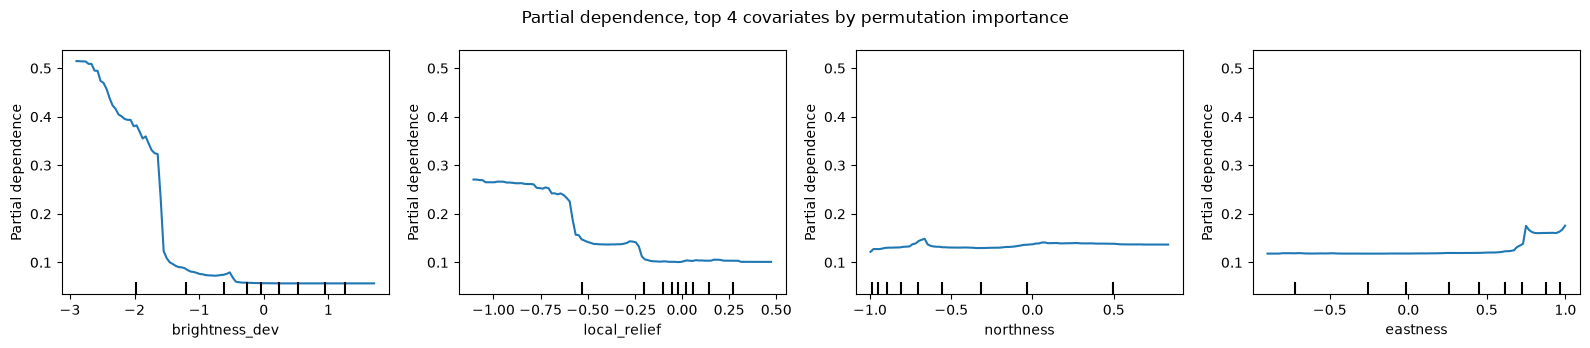

In [7]:
top_features = importance_df["feature"].head(4).tolist()
top_feature_indices = [FEATURE_COLS.index(f) for f in top_features]

fig, ax = plt.subplots(1, len(top_features), figsize=(4 * len(top_features), 3.5))
PartialDependenceDisplay.from_estimator(
    rf_full, X, top_feature_indices, feature_names=FEATURE_COLS, ax=ax
)
fig.suptitle("Partial dependence, top 4 covariates by permutation importance")
fig.tight_layout()

## Full-raster susceptibility surface + sanity check

Point-level stats have overestimated full-raster performance three separate times already this project (DevFromMeanElev, spectral brightness, the combined test) -- so no importance ranking gets trusted until it's checked against an actual raster output, not just the 334 sampled points.

Native 5 cm resolution over the full AOI is ~600M+ pixels, which is not a reasonable amount of data to push through 500-tree `predict_proba` for a first pass -- coarsened to `PRED_RESOLUTION_M` for this sanity check only. The point-level model/importance analysis above is unaffected; this is purely about generating a plausibility-checkable map quickly.

In [8]:
from rasterio.features import geometry_mask
from rasterio.warp import calculate_default_transform

PRED_RESOLUTION_M = 0.5

with rasterio.open(COVARIATE_RASTERS["local_relief"]) as ref:
    ref_crs = ref.crs
    dst_transform, dst_width, dst_height = calculate_default_transform(
        ref.crs, ref.crs, ref.width, ref.height, *ref.bounds, resolution=PRED_RESOLUTION_M
    )


def _reproject_to_grid(path, resampling):
    with rasterio.open(path) as src:
        dst = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_transform, dst_crs=ref_crs,
            resampling=resampling,
            src_nodata=src.nodata,
            dst_nodata=np.nan,
        )
    return dst


stack = {name: _reproject_to_grid(path, Resampling.average) for name, path in COVARIATE_RASTERS.items()}

geomorphon_grid = _reproject_to_grid(GEOMORPHON_RASTER, Resampling.nearest)
geomorphon_grid = np.nan_to_num(geomorphon_grid, nan=-1).round().astype(int)
for col in geomorphon_dummies.columns:
    class_id = int(col.split("_")[1])
    stack[col] = (geomorphon_grid == class_id).astype(np.float32)

pred_X = np.column_stack([stack[f].ravel() for f in FEATURE_COLS])

# AOI polygon mask -- clip_to_aoi fills outside-AOI pixels with 0, not a true
# nodata value, so isfinite alone wouldn't catch them; rasterize the real AOI
# boundary instead. Combined with isfinite as a safety net for any other gaps
# (e.g. brightness/ortho coverage not perfectly matching the DSM extent).
aoi_mask = geometry_mask(
    aoi.geometry, out_shape=(dst_height, dst_width), transform=dst_transform, invert=True
)
valid = aoi_mask.ravel() & np.isfinite(pred_X).all(axis=1)
print(f"{valid.sum():,} / {valid.size:,} pixels valid ({valid.mean():.0%})")

proba = np.full(pred_X.shape[0], np.nan, dtype=np.float32)
proba[valid] = rf_full.predict_proba(pred_X[valid])[:, 1]
proba_grid = proba.reshape(dst_height, dst_width)

out_path = PROCESSED / f"{DATE}_susceptibility.tif"
PROCESSED.mkdir(parents=True, exist_ok=True)
out_profile = {
    "driver": "GTiff", "height": dst_height, "width": dst_width,
    "count": 1, "dtype": "float32", "crs": ref_crs, "transform": dst_transform,
    "nodata": np.nan,
}
with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(proba_grid, 1)
print(f"saved susceptibility surface to {out_path} ({dst_width}x{dst_height} @ {PRED_RESOLUTION_M} m)")

1,667,276 / 3,470,124 pixels valid (48%)


saved susceptibility surface to data\processed\20250820_susceptibility.tif (3052x1137 @ 0.5 m)


In [9]:
from scipy import ndimage

manual_proba = sample_raster(out_path, manual_points)

print("threshold | recall (34 manual pts) | connected regions above threshold")
for t in [0.3, 0.5, 0.7, 0.9]:
    recall = np.nanmean(manual_proba >= t)
    mask = np.nan_to_num(proba_grid, nan=0) >= t
    _, n_regions = ndimage.label(mask, structure=np.ones((3, 3)))
    print(f"  {t:.1f}      | {recall:.0%} ({int(np.nansum(manual_proba >= t))}/34) "
          f"          | {n_regions:,}")

threshold | recall (34 manual pts) | connected regions above threshold
  0.3      | 79% (27/34)           | 3,256
  0.5      | 62% (21/34)           | 417
  0.7      | 56% (19/34)           | 187
  0.9      | 29% (10/34)           | 53
